## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [119]:
import pandas
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [120]:
data = pandas.read_csv("QueryResults.csv", names=["DATE", "TAG", "POSTS"], header = 0)
df = pandas.DataFrame(data)
print(df.columns)

Index(['DATE', 'TAG', 'POSTS'], dtype='str')


**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

print(df.head())
print(df.tail())

**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [121]:
print(df.shape)

(1991, 3)


**Challenge**: Count the number of entries in each column of the dataframe

In [122]:
print(df.count())


DATE     1991
TAG      1991
POSTS    1991
dtype: int64


**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [123]:
print(df.groupby("TAG").POSTS.sum().sort_values(ascending=False))

TAG
javascript    2056510
java          1696403
python        1496210
c#            1423530
php           1361988
c++            684210
r              356799
c              336042
swift          273055
ruby           214582
perl            65286
go              47499
delphi          46212
assembly        34852
Name: POSTS, dtype: int64


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [124]:
print(df.groupby("TAG").DATE.count().sort_values(ascending=True))

TAG
go            129
swift         135
r             142
assembly      144
java          144
delphi        144
c++           144
c             144
python        144
javascript    144
php           144
perl          144
ruby          144
c#            145
Name: DATE, dtype: int64


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [125]:
df.DATE = pandas.to_datetime(df.DATE)
print(df.head())

        DATE         TAG  POSTS
0 2008-07-01          c#      3
1 2008-08-01    assembly      8
2 2008-08-01  javascript    162
3 2008-08-01           c     85
4 2008-08-01      python    124


## Data Manipulation



In [126]:
reshaped_df = df.pivot(index = "DATE", columns = "TAG", values = "POSTS")
print(reshaped_df)

TAG         assembly       c       c#     c++  delphi     go     java  \
DATE                                                                    
2008-07-01       NaN     NaN      3.0     NaN     NaN    NaN      NaN   
2008-08-01       8.0    85.0    511.0   164.0    14.0    NaN    222.0   
2008-09-01      28.0   321.0   1649.0   755.0   105.0    NaN   1137.0   
2008-10-01      15.0   303.0   1989.0   811.0   112.0    NaN   1153.0   
2008-11-01      17.0   259.0   1730.0   735.0   141.0    NaN    958.0   
...              ...     ...      ...     ...     ...    ...      ...   
2020-03-01     317.0  2670.0   8954.0  5107.0   181.0  719.0  13253.0   
2020-04-01     406.0  3472.0  10042.0  6820.0   250.0  887.0  15377.0   
2020-05-01     386.0  3602.0   9923.0  7063.0   221.0  826.0  14711.0   
2020-06-01     363.0  2757.0   9064.0  6161.0   214.0  765.0  13015.0   
2020-07-01     298.0  2294.0   9145.0  5756.0   212.0  743.0  12723.0   

TAG         javascript   perl     php   python    

**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [127]:
print(reshaped_df.shape)

(145, 14)


In [128]:
print(reshaped_df.columns)

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')


In [129]:
print(reshaped_df.head())

TAG         assembly      c      c#    c++  delphi  go    java  javascript  \
DATE                                                                         
2008-07-01       NaN    NaN     3.0    NaN     NaN NaN     NaN         NaN   
2008-08-01       8.0   85.0   511.0  164.0    14.0 NaN   222.0       162.0   
2008-09-01      28.0  321.0  1649.0  755.0   105.0 NaN  1137.0       640.0   
2008-10-01      15.0  303.0  1989.0  811.0   112.0 NaN  1153.0       725.0   
2008-11-01      17.0  259.0  1730.0  735.0   141.0 NaN   958.0       579.0   

TAG          perl    php  python    r   ruby  swift  
DATE                                                 
2008-07-01    NaN    NaN     NaN  NaN    NaN    NaN  
2008-08-01   28.0  161.0   124.0  NaN   73.0    NaN  
2008-09-01  131.0  482.0   542.0  6.0  290.0    NaN  
2008-10-01  127.0  617.0   510.0  NaN  249.0    NaN  
2008-11-01   97.0  504.0   452.0  1.0  160.0    NaN  


**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [130]:
print(reshaped_df.count())

TAG
assembly      144
c             144
c#            145
c++           144
delphi        144
go            129
java          144
javascript    144
perl          144
php           144
python        144
r             142
ruby          144
swift         135
dtype: int64


In [131]:
reshaped_df.fillna(0, inplace = True)
print(reshaped_df)

TAG         assembly       c       c#     c++  delphi     go     java  \
DATE                                                                    
2008-07-01       0.0     0.0      3.0     0.0     0.0    0.0      0.0   
2008-08-01       8.0    85.0    511.0   164.0    14.0    0.0    222.0   
2008-09-01      28.0   321.0   1649.0   755.0   105.0    0.0   1137.0   
2008-10-01      15.0   303.0   1989.0   811.0   112.0    0.0   1153.0   
2008-11-01      17.0   259.0   1730.0   735.0   141.0    0.0    958.0   
...              ...     ...      ...     ...     ...    ...      ...   
2020-03-01     317.0  2670.0   8954.0  5107.0   181.0  719.0  13253.0   
2020-04-01     406.0  3472.0  10042.0  6820.0   250.0  887.0  15377.0   
2020-05-01     386.0  3602.0   9923.0  7063.0   221.0  826.0  14711.0   
2020-06-01     363.0  2757.0   9064.0  6161.0   214.0  765.0  13015.0   
2020-07-01     298.0  2294.0   9145.0  5756.0   212.0  743.0  12723.0   

TAG         javascript   perl     php   python    

In [132]:
reshaped_df.isna().values.any()

np.False_

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

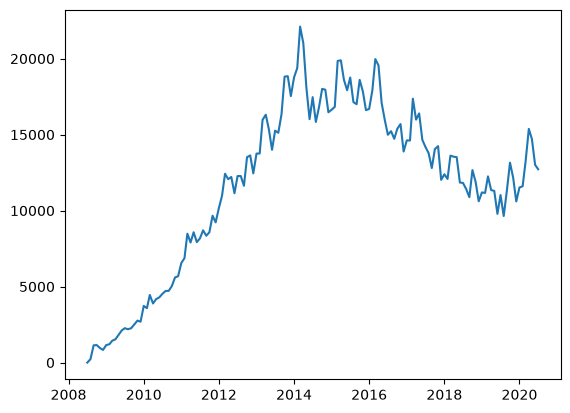

In [137]:
plt.plot(reshaped_df.index, reshaped_df.java)

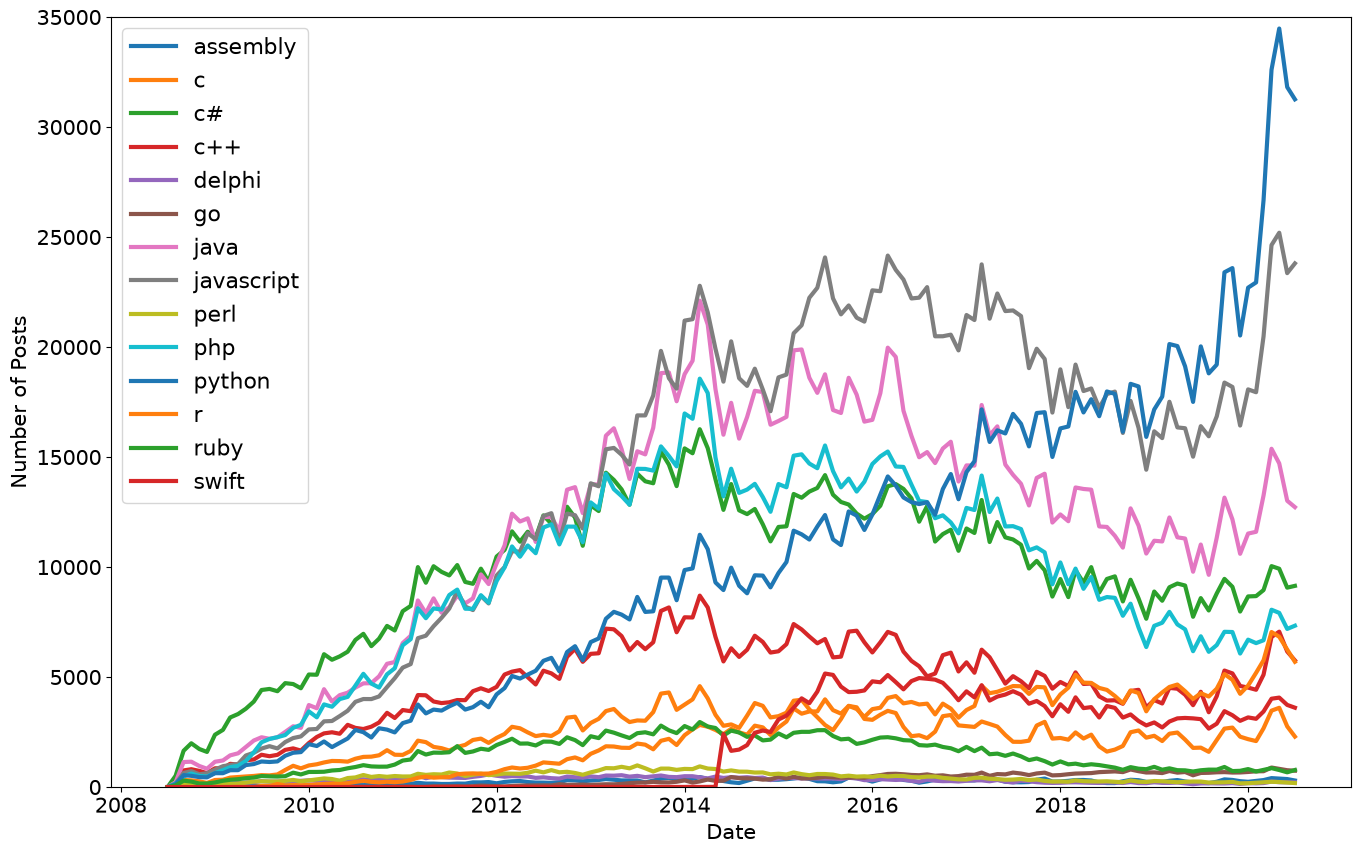

In [152]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Date", fontsize=15)
plt.ylabel("Number of Posts", fontsize=15)
plt.ylim(0, 35000)

for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column],
             linewidth=3, label=column)

plt.legend(fontsize=16)

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

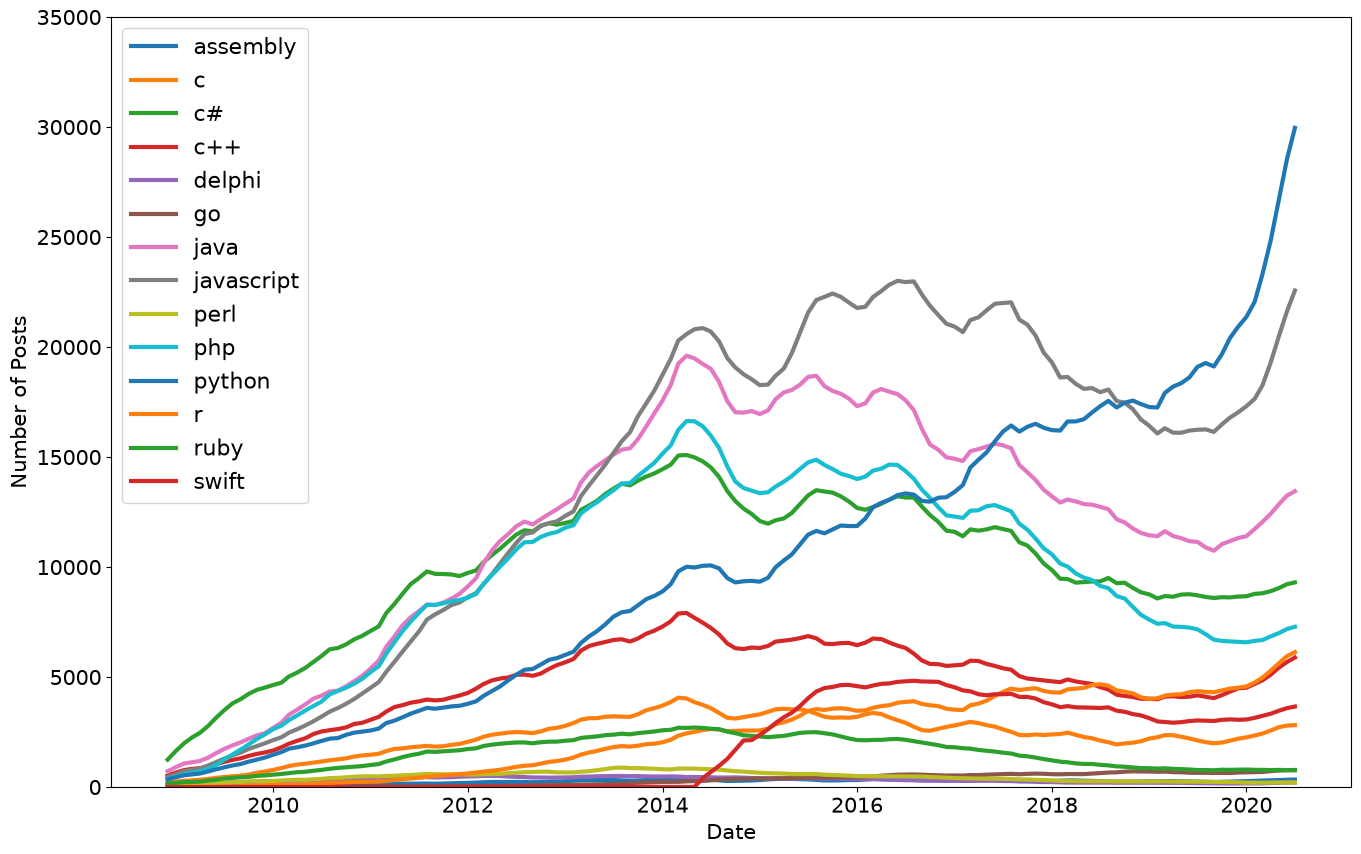

In [163]:
roll_df = reshaped_df.rolling(window = 6).mean()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Date", fontsize=15)
plt.ylabel("Number of Posts", fontsize=15)
plt.ylim(0, 35000)

for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column],
             linewidth=3, label=column)

plt.legend(fontsize=16)